# How to Train a RF-DETR Instance Segmentation Model with Custom Data

We will show you how to train a RF-DETR instance segmentation model with your images and annotations and export to a Core ML model which can be used for auto labeling on RectLabel.

### Use GPU

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Runtime` -> `Change runtime type` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Fri Mar 27 15:41:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install PyTorch 2.8.0

In [3]:
!pip install -q torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128


### Install RF-DETR 1.5.1

In [ ]:
!pip install -q rfdetr==1.5.1

### Download training images and annotations

Download training images and annotations. You can use these or replace them with your own data.

In [5]:
!mkdir datasets
%cd datasets
!wget -q https://huggingface.co/datasets/rectlabel/datasets/resolve/main/donut_coco.zip
!unzip -q donut_coco.zip
%cd ..

/content/datasets
/content


### Fine-tune RF-DETR on custom dataset

Start training from the current content folder.

In [6]:
from rfdetr import RFDETRSegNano

model = RFDETRSegNano()
dataset_dir = "datasets/donut_coco"
model.train(dataset_dir=dataset_dir, epochs=20, batch_size=4, grad_accum_steps=4)

[2026-03-27 15:44:53] [INFO] rf-detr - Downloading pretrained weights for rf-detr-seg-nano.pt


rf-detr-seg-nano.pt:   0%|          | 0.00/128M [00:00<?, ?iB/s]

[2026-03-27 15:45:03] [INFO] rf-detr - MD5 validation successful for rf-detr-seg-nano.pt


[2026-03-27 15:45:03] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-27 15:45:03] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-27 15:45:04] [INFO] rf-detr - Loading pretrain weights


...

[2026-03-27 15:52:50] [INFO] rf-detr - Epoch: [16/20]  [0/5]  eta: 0:00:41  lr: 0.000100  class_error: 0.00  loss: 14.0045 (14.0045)  loss_ce: 1.0747 (1.0747)  loss_bbox: 0.0920 (0.0920)  loss_giou: 0.0883 (0.0883)  loss_mask_ce: 0.0946 (0.0946)  loss_mask_dice: 0.0877 (0.0877)  loss_ce_0: 4.3798 (4.3798)  loss_bbox_0: 0.0827 (0.0827)  loss_giou_0: 0.0821 (0.0821)  loss_mask_ce_0: 0.1042 (0.1042)  loss_mask_dice_0: 0.0932 (0.0932)  loss_ce_1: 2.3396 (2.3396)  loss_bbox_1: 0.0885 (0.0885)  loss_giou_1: 0.0955 (0.0955)  loss_mask_ce_1: 0.0976 (0.0976)  loss_mask_dice_1: 0.0922 (0.0922)  loss_ce_2: 1.4141 (1.4141)  loss_bbox_2: 0.0769 (0.0769)  loss_giou_2: 0.0855 (0.0855)  loss_mask_ce_2: 0.0927 (0.0927)  loss_mask_dice_2: 0.0837 (0.0837)  loss_ce_enc: 2.4214 (2.4214)  loss_bbox_enc: 0.3350 (0.3350)  loss_giou_enc: 0.2974 (0.2974)  loss_mask_ce_enc: 0.1562 (0.1562)  loss_mask_dice_enc: 0.1491 (0.1491)  loss_ce_unscaled: 0.2149 (0.2149)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_un

[2026-03-27 15:53:18] [INFO] rf-detr - Epoch: [17/20]  [0/5]  eta: 0:00:36  lr: 0.000100  class_error: 0.00  loss: 14.9143 (14.9143)  loss_ce: 1.2038 (1.2038)  loss_bbox: 0.1225 (0.1225)  loss_giou: 0.1109 (0.1109)  loss_mask_ce: 0.1497 (0.1497)  loss_mask_dice: 0.1411 (0.1411)  loss_ce_0: 4.3691 (4.3691)  loss_bbox_0: 0.1266 (0.1266)  loss_giou_0: 0.1213 (0.1213)  loss_mask_ce_0: 0.1835 (0.1835)  loss_mask_dice_0: 0.1693 (0.1693)  loss_ce_1: 2.1447 (2.1447)  loss_bbox_1: 0.1163 (0.1163)  loss_giou_1: 0.1152 (0.1152)  loss_mask_ce_1: 0.1779 (0.1779)  loss_mask_dice_1: 0.1669 (0.1669)  loss_ce_2: 1.4785 (1.4785)  loss_bbox_2: 0.1155 (0.1155)  loss_giou_2: 0.1115 (0.1115)  loss_mask_ce_2: 0.1719 (0.1719)  loss_mask_dice_2: 0.1633 (0.1633)  loss_ce_enc: 2.3025 (2.3025)  loss_bbox_enc: 0.3090 (0.3090)  loss_giou_enc: 0.2636 (0.2636)  loss_mask_ce_enc: 0.2899 (0.2899)  loss_mask_dice_enc: 0.2897 (0.2897)  loss_ce_unscaled: 0.2408 (0.2408)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_un

[2026-03-27 15:53:47] [INFO] rf-detr - Epoch: [18/20]  [0/5]  eta: 0:00:38  lr: 0.000100  class_error: 0.00  loss: 12.1911 (12.1911)  loss_ce: 0.9217 (0.9217)  loss_bbox: 0.0648 (0.0648)  loss_giou: 0.0682 (0.0682)  loss_mask_ce: 0.0972 (0.0972)  loss_mask_dice: 0.0898 (0.0898)  loss_ce_0: 4.0975 (4.0975)  loss_bbox_0: 0.0703 (0.0703)  loss_giou_0: 0.0696 (0.0696)  loss_mask_ce_0: 0.1098 (0.1098)  loss_mask_dice_0: 0.0984 (0.0984)  loss_ce_1: 1.8580 (1.8580)  loss_bbox_1: 0.0772 (0.0772)  loss_giou_1: 0.0745 (0.0745)  loss_mask_ce_1: 0.1088 (0.1088)  loss_mask_dice_1: 0.0983 (0.0983)  loss_ce_2: 1.1233 (1.1233)  loss_bbox_2: 0.0681 (0.0681)  loss_giou_2: 0.0684 (0.0684)  loss_mask_ce_2: 0.1112 (0.1112)  loss_mask_dice_2: 0.1020 (0.1020)  loss_ce_enc: 2.0523 (2.0523)  loss_bbox_enc: 0.2406 (0.2406)  loss_giou_enc: 0.2138 (0.2138)  loss_mask_ce_enc: 0.1545 (0.1545)  loss_mask_dice_enc: 0.1528 (0.1528)  loss_ce_unscaled: 0.1843 (0.1843)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_un

[2026-03-27 15:54:18] [INFO] rf-detr - Epoch: [19/20]  [0/5]  eta: 0:00:38  lr: 0.000100  class_error: 0.00  loss: 16.5886 (16.5886)  loss_ce: 1.5834 (1.5834)  loss_bbox: 0.2640 (0.2640)  loss_giou: 0.1855 (0.1855)  loss_mask_ce: 0.0998 (0.0998)  loss_mask_dice: 0.1287 (0.1287)  loss_ce_0: 4.7705 (4.7705)  loss_bbox_0: 0.2580 (0.2580)  loss_giou_0: 0.1764 (0.1764)  loss_mask_ce_0: 0.1095 (0.1095)  loss_mask_dice_0: 0.1359 (0.1359)  loss_ce_1: 2.4106 (2.4106)  loss_bbox_1: 0.2552 (0.2552)  loss_giou_1: 0.1788 (0.1788)  loss_mask_ce_1: 0.0957 (0.0957)  loss_mask_dice_1: 0.1257 (0.1257)  loss_ce_2: 1.6013 (1.6013)  loss_bbox_2: 0.2510 (0.2510)  loss_giou_2: 0.1670 (0.1670)  loss_mask_ce_2: 0.0969 (0.0969)  loss_mask_dice_2: 0.1177 (0.1177)  loss_ce_enc: 2.3679 (2.3679)  loss_bbox_enc: 0.4461 (0.4461)  loss_giou_enc: 0.3387 (0.3387)  loss_mask_ce_enc: 0.1833 (0.1833)  loss_mask_dice_enc: 0.2412 (0.2412)  loss_ce_unscaled: 0.3167 (0.3167)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_un

[2026-03-27 15:54:52] [INFO] rf-detr - Epoch: [20/20]  [0/5]  eta: 0:00:41  lr: 0.000100  class_error: 0.00  loss: 14.9972 (14.9972)  loss_ce: 1.3469 (1.3469)  loss_bbox: 0.0837 (0.0837)  loss_giou: 0.1161 (0.1161)  loss_mask_ce: 0.1043 (0.1043)  loss_mask_dice: 0.1301 (0.1301)  loss_ce_0: 4.2066 (4.2066)  loss_bbox_0: 0.1193 (0.1193)  loss_giou_0: 0.1568 (0.1568)  loss_mask_ce_0: 0.1099 (0.1099)  loss_mask_dice_0: 0.1722 (0.1722)  loss_ce_1: 2.6018 (2.6018)  loss_bbox_1: 0.0916 (0.0916)  loss_giou_1: 0.1283 (0.1283)  loss_mask_ce_1: 0.1143 (0.1143)  loss_mask_dice_1: 0.1644 (0.1644)  loss_ce_2: 1.5773 (1.5773)  loss_bbox_2: 0.0969 (0.0969)  loss_giou_2: 0.1321 (0.1321)  loss_mask_ce_2: 0.1136 (0.1136)  loss_mask_dice_2: 0.1653 (0.1653)  loss_ce_enc: 2.2609 (2.2609)  loss_bbox_enc: 0.2630 (0.2630)  loss_giou_enc: 0.3157 (0.3157)  loss_mask_ce_enc: 0.1536 (0.1536)  loss_mask_dice_enc: 0.2725 (0.2725)  loss_ce_unscaled: 0.2694 (0.2694)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_un

Check training and validation loss.

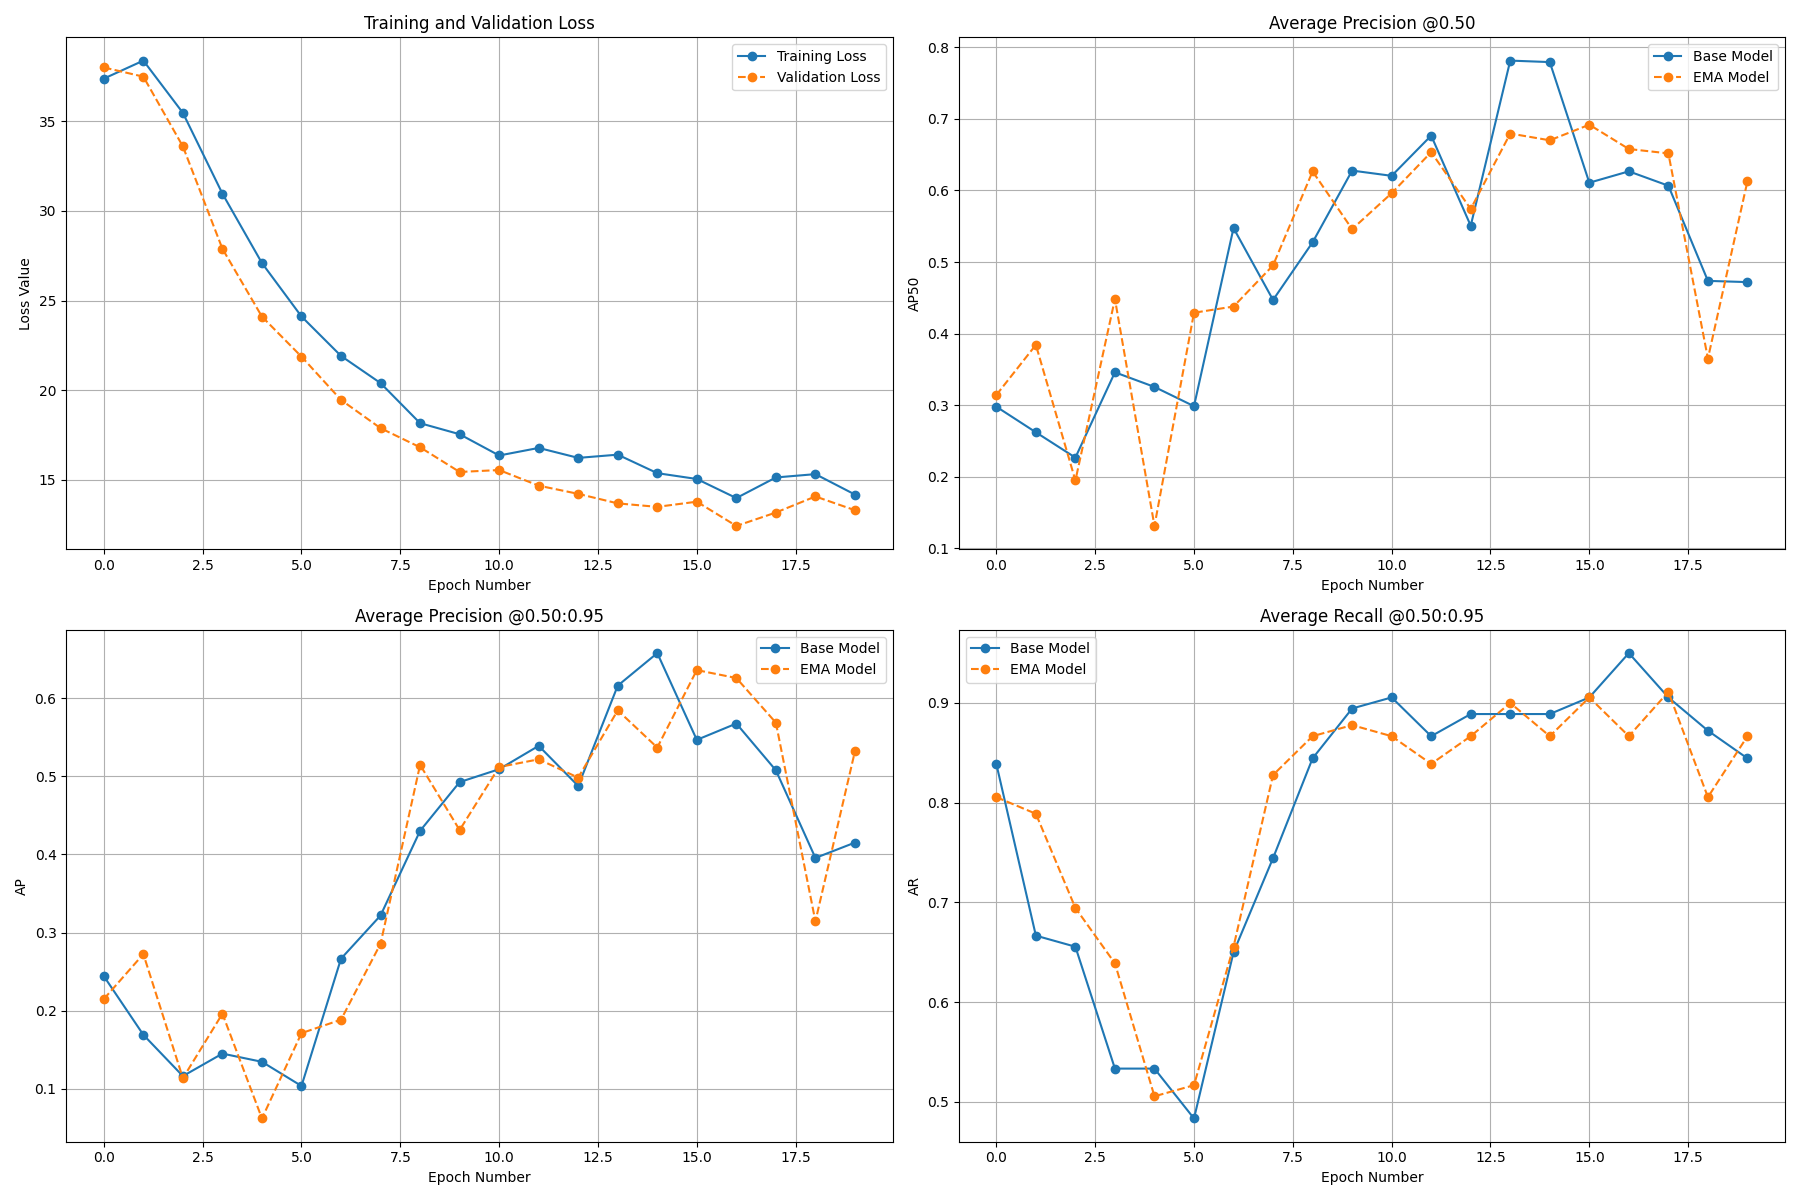

In [7]:
from PIL import Image

Image.open("/content/output/metrics_plot.png")

The trained model is checkpoint_best_total.pth.

In [8]:
!ls -la /content/output

total 2479740
drwxr-xr-x 3 root root      4096 Mar 27 15:55 .
drwxr-xr-x 1 root root      4096 Mar 27 15:45 ..
-rw-r--r-- 1 root root 534398511 Mar 27 15:50 checkpoint0009.pth
-rw-r--r-- 1 root root 534398511 Mar 27 15:55 checkpoint0019.pth
-rw-r--r-- 1 root root 399873726 Mar 27 15:48 checkpoint_best_ema.pth
-rw-r--r-- 1 root root 401162890 Mar 27 15:52 checkpoint_best_regular.pth
-rw------- 1 root root 134529047 Mar 27 15:55 checkpoint_best_total.pth
-rw-r--r-- 1 root root 534387619 Mar 27 15:55 checkpoint.pth
drwxr-xr-x 2 root root      4096 Mar 27 15:45 eval
-rw-r--r-- 1 root root      8752 Mar 27 15:55 events.out.tfevents.1774626305.7123e47d9cdc.1829.0
-rw-r--r-- 1 root root    223784 Mar 27 15:55 log.txt
-rw-r--r-- 1 root root    212392 Mar 27 15:55 metrics_plot.png
-rw-r--r-- 1 root root       872 Mar 27 15:55 results.json


### Install RF-DETR to CoreML

In [9]:
!git clone https://github.com/landchenxuan/rf-detr-to-coreml.git
%cd rf-detr-to-coreml
!pip install -q -e .

Cloning into 'rf-detr-to-coreml'...
remote: Enumerating objects: 99, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 99 (delta 38), reused 87 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (99/99), 1.71 MiB | 35.12 MiB/s, done.
Resolving deltas: 100% (38/38), done.
/content/rf-detr-to-coreml
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.2 MB/s eta 0:00:00
  Building editable for rfdetr-coreml (pyproject.toml) ... done


Move the best model to the current folder and export to a Core ML model.

In [10]:
!mv /content/output/checkpoint_best_total.pth .

In [11]:
!rfdetr-coreml --model seg-nano --weights checkpoint_best_total.pth

scikit-learn version 1.6.1 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
XGBoost version 3.2.0 has not been tested with coremltools. You may run into unexpected errors. XGBoost 1.4.2 is the most recent version that has been tested.
2026-03-27 16:01:43.738781: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774627303.766414    7901 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774627303.776218    7901 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774627303.812127    7901 computation_placer.cc:177] computation placer already registered. Please check linkage and 

In [12]:
!ls -la output

total 12
drwxr-xr-x 3 root root 4096 Mar 27 16:02 .
drwxr-xr-x 7 root root 4096 Mar 27 16:02 ..
drwxr-xr-x 3 root root 4096 Mar 27 16:02 rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage


In [13]:
%cd output

/content/rf-detr-to-coreml/output


Zip the Core ML model and download it from the File browser at the left hand. You can auto label images using the Core ML model on RectLabel.

In [14]:
!zip -r seg-nano.zip rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage

  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/model.mlmodel (deflated 89%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/weights/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/weights/weight.bin (deflated 7%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Manifest.json (deflated 59%)
